In [2]:
import numpy as np
import pandas as pd
import multiprocessing as mp
import researchpy as rp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
import torch.nn.functional as F
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

In [14]:
def toDataFrame(glob_path, col_name, col_index, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d])

    df['method'] = method

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()
    df.loc[len(df.index)] = [0] * df.shape[1]
    # df.reset_index()
    # print(df)
    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.sum(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    result_df['method'] = method

    return result_df

sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
sns.set_palette(palette)

        0       1       2       3       4       5       6       7       8  \
0   73718   73760   74240   74210   74634   74178   74350   75711   77051   
1   75146   75010   74768   74858   74777   74950   75055   75291   77253   
2   74051   75306   74964   75232   74691   75197   75302   75834   77381   
3   72650   73326   73424   73729   73139   73574   73242   73602   75641   
4  142841  128750  125252  120221  122569  120197  109170  116449  124272   
5   74109   73888   74215   74048   74526   74372   74251   75515   76394   
6   73411   73682   73342   73149   73425   73508   73352   74015   75784   
7   74970   73237   73204   74092   73494   73436   73659   73735   75917   
8   73551   74280   73763   74211   73902   74061   74316   74566   75763   
9   72504   73326   73519   73567   73643   73359   73853   75123   75992   

        9  ...      20      21      22      23      24      25      26  \
0   83952  ...   84993   85381   85136   85757   85593   86239   85745   
1   

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


KeyError: 0

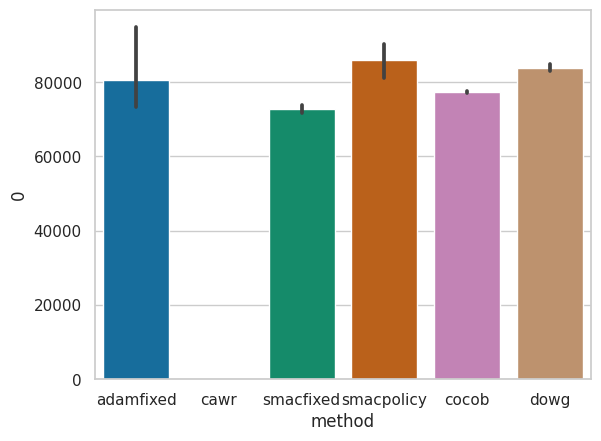

In [19]:
cocob_ta_mnist = toDataFrame('./results_cluster/results/COCOB_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'cocob')
adamfixed_ta_mnist = toDataFrame('./results_cluster/results/Adam_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'adamfixed')
smacfixed_ta_mnist = toDataFrame('./results_cluster/results/SMAC_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacfixed')
cawr_ta_mnist = toChunkedDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 750, "cawr")
print(cawr_ta_mnist)
smacpolicy_ta_mnist = toDataFrame('./results_cluster/results/smacpolicy_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacpolicy')
dowg_ta_mnist = toDataFrame('./results_cluster/results/DoWG_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'dowg')
cdowg_ta_mnist = toDataFrame('./results_cluster/results/CDoWG_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'cdowg')
data = pd.concat([adamfixed_ta_mnist, cawr_ta_mnist, smacfixed_ta_mnist, smacpolicy_ta_mnist, cocob_ta_mnist, dowg_ta_mnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_mnist[0]))
print(rp.summary_cont(cawr_ta_mnist[0]))
print(rp.summary_cont(smacfixed_ta_mnist[0]))
print(rp.summary_cont(smacpolicy_ta_mnist[0]))
print(rp.summary_cont(cocob_ta_mnist[0]))
print(rp.summary_cont(dowg_ta_mnist[0]))
# print(rp.summary_cont(cdowg_ta_mnist[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9265  0.0018  0.0006     0.9252    0.9277


   Variable     N   Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.911  0.0037  0.0012     0.9083    0.9136


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9191  0.0056  0.0018     0.9151    0.9231


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.9237  0.0041  0.0014     0.9206    0.9269


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9244  0.0025  0.0008     0.9226    0.9261


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8702  0.0737  0.0233     0.8174    0.9229


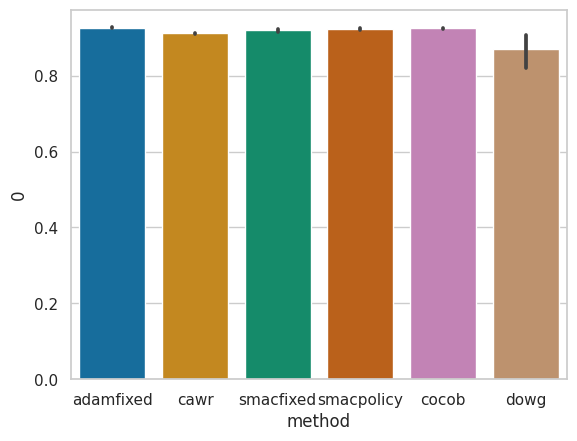

In [11]:
cocob_ta_fmnist = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_fmnist = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_fmnist = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
cawr_ta_fmnist = toDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
smacpolicy_ta_fmnist = toDataFrame('./results_cluster/results/smacpolicy_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
dowg_ta_fmnist = toDataFrame('./results_cluster/results/DoWG_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
data = pd.concat([adamfixed_ta_fmnist, cawr_ta_fmnist, smacfixed_ta_fmnist, smacpolicy_ta_fmnist, cocob_ta_fmnist, dowg_ta_fmnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_fmnist[0]))
print(rp.summary_cont(cawr_ta_fmnist[0]))
print(rp.summary_cont(smacfixed_ta_fmnist[0]))
print(rp.summary_cont(smacpolicy_ta_fmnist[0]))
print(rp.summary_cont(cocob_ta_fmnist[0]))
print(rp.summary_cont(dowg_ta_fmnist[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8479  0.0078  0.0025     0.8423    0.8535


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8759  0.0017  0.0005     0.8747    0.8771


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8538  0.0083  0.0026     0.8478    0.8597


   Variable    N    Mean    SD      SE  95% Conf.  Interval
0       0.0  9.0  0.8698  0.01  0.0033      0.862    0.8775


   Variable     N    Mean    SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8255  0.01  0.0032     0.8183    0.8327


   Variable     N   Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.841  0.0125  0.0039      0.832    0.8499


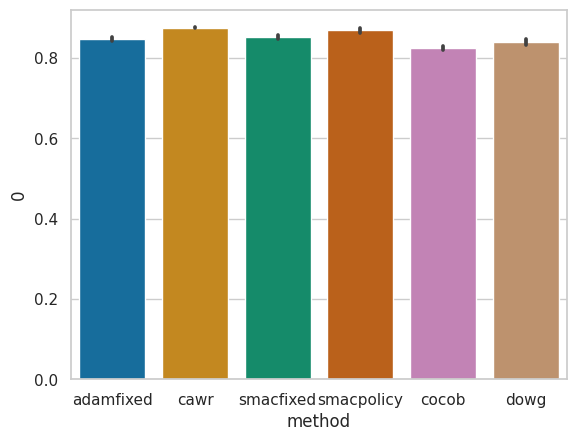

In [5]:
cocob_ta_cifar10 = toDataFrame('./results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar10 = toDataFrame('./results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
# stormplus_cifar10 = toDataFrame('./results_cluster/results/STORMplus_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'stormplus')
smacfixed_ta_cifar10 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
smacpolicy_ta_cifar10 = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
# smacpolicy_ta_cifar10_seed = toDataFrame('./results_cluster/results/smacpolicy_cifar10_same_seed/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicyseed')
dowg_ta_cifar10 = toDataFrame('./results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
cawr_ta_cifar10 = toDataFrame('./results_cluster/results/CAWR_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([adamfixed_ta_cifar10, cawr_ta_cifar10, smacfixed_ta_cifar10, smacpolicy_ta_cifar10, cocob_ta_cifar10, dowg_ta_cifar10])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_cifar10[0]))
print(rp.summary_cont(cawr_ta_cifar10[0]))
print(rp.summary_cont(smacfixed_ta_cifar10[0]))
print(rp.summary_cont(smacpolicy_ta_cifar10[0]))
# print(rp.summary_cont(smacpolicy_ta_cifar10_seed[0]))
print(rp.summary_cont(cocob_ta_cifar10[0]))
print(rp.summary_cont(dowg_ta_cifar10[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5692  0.0057  0.0018     0.5651    0.5732


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.6018  0.0043  0.0014     0.5987    0.6049


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5742  0.0065  0.0021     0.5696    0.5789


   Variable    N    Mean     SD     SE  95% Conf.  Interval
0       0.0  9.0  0.5811  0.018  0.006     0.5673    0.5949


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5406  0.0041  0.0013     0.5377    0.5436


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5376  0.0057  0.0018     0.5335    0.5417


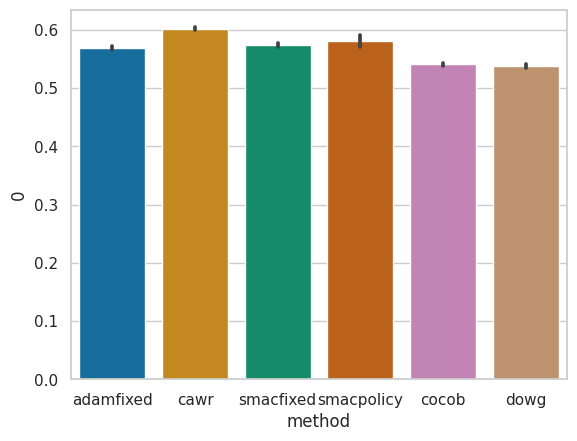

In [6]:
cocob_ta_cifar100 = toDataFrame('./results_cluster/results/COCOB_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar100 = toDataFrame('./results_cluster/results/Adam_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
dowg_cifar100 = toDataFrame('./results_cluster/results/DoWG_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
smacfixed_ta_cifar100 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
smacpolicy_ta_cifar100 = toDataFrame('./results_cluster/results/smacpolicy_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
cawr_ta_cifar100 = toDataFrame('./results_cluster/results/CAWR_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([adamfixed_ta_cifar100, cawr_ta_cifar100, smacfixed_ta_cifar100, smacpolicy_ta_cifar100, cocob_ta_cifar100, dowg_cifar100])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_cifar100[0]))
print(rp.summary_cont(cawr_ta_cifar100[0]))
print(rp.summary_cont(smacfixed_ta_cifar100[0]))
print(rp.summary_cont(smacpolicy_ta_cifar100[0]))
print(rp.summary_cont(cocob_ta_cifar100[0]))
print(rp.summary_cont(dowg_cifar100[0]))


Text(0, 0.5, 'Learning Rate')

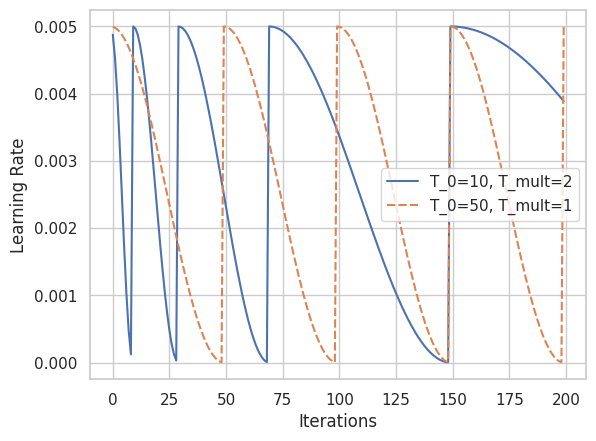

In [26]:
from dacbench_custom.cosine_annealing_agent import CosineAnnealingWRAgent as CAWR

def cawr_df(cawr):
    values = []
    for i in range(200):
        values.append(cawr.act())
    
    return pd.DataFrame(values)

cawr = CAWR(None, 10, 0, 0.005, 2)
cawr2 = CAWR(None, 50, 0, 0.005, 1)

df = pd.concat([cawr_df(cawr), cawr_df(cawr2)], axis=1)

df.columns = ['T_0=10, T_mult=2', 'T_0=50, T_mult=1']

sns.lineplot(data=df)
plt.xlabel('Iterations')
plt.ylabel('Learning Rate')

In [19]:
import json

# Opening JSON file
f = open('results_cluster/results/smacpolicy_cifar10_1/smac3_output/6c4a05b0072ba1156e3b55cb5b61b515/1/runhistory.json')

# returns JSON object as 
# a dictionary
data = json.load(f)

# Iterating through the json
# list
maxI = data['data'][0]
for i in data['data']:
    if i[4] < maxI[4]:
        maxI = i

print(maxI)

print(data['configs']['{}'.format(maxI[0])])

# Closing file
f.close()

[237, None, 1791095845, None, -0.08104356568132003, 22648.893430233, 1, 1723755257.0392883, 1723777905.9342346, {}]
{'x0': 0.001529885706290909, 'x1': 0.002794182531201569, 'x10': 0.00304654136353216, 'x11': 0.004892258077537285, 'x12': 0.002378748332705129, 'x13': 0.0024472413321039543, 'x14': 0.0021153548079027346, 'x15': 0.0017059255443778332, 'x16': 0.0024692999194684474, 'x17': 0.004513075879525776, 'x18': 0.003643061512008205, 'x19': 0.002181398056240455, 'x2': 0.004804014239871173, 'x20': 3.4681871298153854e-05, 'x21': 0.0012177597943052799, 'x22': 0.003987806919179982, 'x23': 0.0038958154856253723, 'x24': 0.003982681457233959, 'x25': 0.004135128759578226, 'x26': 0.004198129582126079, 'x27': 0.0018751477867694603, 'x28': 0.003783942958199853, 'x29': 0.0010626152504533786, 'x3': 0.00479072738415169, 'x4': 0.004882868183840954, 'x5': 0.004766662664630416, 'x6': 0.0015985545015721704, 'x7': 0.003961006145149245, 'x8': 0.00136052314675375, 'x9': 0.0024146632656460772}
